# Data Cleaning and Validation

In [1]:
%pip install -q pandas

Note: you may need to restart the kernel to use updated packages.


## Load and inspect the raw data

In [2]:
import pandas as pd

orders = pd.read_csv('orders_raw.csv')
products = pd.read_csv('products.csv')
print(orders.shape, products.shape)

(508, 11) (31, 5)


In [3]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


In [4]:
orders.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [5]:
orders['status'].value_counts()

status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

The inspection above shows four data quality issues:

1. The raw file has more rows than expected, 508 instead of 500, because 8 order_id values are duplicated.
2. The city and category columns have mixed casing and stray whitespace, for example ' Bengaluru ', 'BENGALURU', and 'bengaluru' all referring to the same city.
3. amount_inr has missing values, 10 rows have no value recorded.
4. amount_inr has suspiciously large values, the median is around 168 but the maximum reaches 7600, far above the 75th percentile.

## Remove duplicate rows

In [6]:
rows_before = len(orders)
orders = orders.drop_duplicates(subset='order_id', keep='first').reset_index(drop=True)
rows_after = len(orders)
rows_removed = rows_before - rows_after
print('rows before:', rows_before)
print('rows after:', rows_after)
print('rows removed:', rows_removed)

rows before: 508
rows after: 500
rows removed: 8


## Fix casing and whitespace

In [7]:
orders['city'] = orders['city'].str.strip().str.title()
orders['category'] = orders['category'].str.strip().str.title()

city_values = sorted(orders['city'].unique())
category_values = sorted(orders['category'].unique())

print('distinct city values:', city_values)
print('distinct category values:', category_values)
print('city count:', len(city_values))
print('category count:', len(category_values))

distinct city values: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
distinct category values: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']
city count: 4
category count: 6


## Handle missing values

In [8]:
missing_amount = orders['amount_inr'].isna().sum()
print('rows with missing amount_inr:', missing_amount)

rows with missing amount_inr: 10


amount_inr is missing for the rows counted above. A missing revenue figure is unknown, not zero, so it is excluded from revenue totals below rather than filled with 0 or a mean. Every revenue calculation later in this notebook drops these rows instead of imputing them.

In [9]:
rating_nulls_by_status = orders.groupby('status')['rating'].apply(lambda s: s.isna().sum())
print(rating_nulls_by_status)

status
Cancelled    42
Delivered     0
Pending      24
Name: rating, dtype: int64


rating is null for every Cancelled and Pending order because only Delivered orders receive a rating from the customer. This is expected, not a data-quality problem, so these nulls are left unfilled and no imputation is applied to the rating column.

## Detect and cap outliers with IQR

In [10]:
delivered_amounts = orders.loc[orders['status'] == 'Delivered', 'amount_inr'].dropna()
q1 = delivered_amounts.quantile(0.25)
q3 = delivered_amounts.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)
print('upper fence:', upper_fence)

Q1: 90.0
Q3: 275.0
IQR: 185.0
upper fence: 552.5


In [11]:
delivered_mask = orders['status'] == 'Delivered'
rows_above_fence = (orders.loc[delivered_mask, 'amount_inr'] > upper_fence).sum()
print('Delivered rows above the upper fence:', rows_above_fence)

Delivered rows above the upper fence: 16


16 Delivered rows sit above the upper fence. This is more than just the 5 synthetic extreme values generate_data.py injects (amount_inr multiplied by 40), reflecting that a real IQR fence also catches some genuinely high but real orders, not just the synthetic extremes.

In [12]:
rows_before_cap = len(orders)
orders.loc[delivered_mask, 'amount_inr'] = orders.loc[delivered_mask, 'amount_inr'].clip(upper=upper_fence)
rows_after_cap = len(orders)
print('rows before capping:', rows_before_cap)
print('rows after capping:', rows_after_cap)
print('rows capped:', rows_above_fence)
print('max Delivered amount_inr after capping:', orders.loc[delivered_mask, 'amount_inr'].max())

rows before capping: 500
rows after capping: 500
rows capped: 16
max Delivered amount_inr after capping: 552.5


## Parse dates and create derived columns

In [13]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month
orders['month_name'] = orders['order_date'].dt.month_name()
orders['revenue_per_unit'] = orders['amount_inr'] / orders['quantity']
orders['is_delivered'] = orders['status'] == 'Delivered'
orders[['order_date', 'month', 'month_name', 'amount_inr', 'quantity', 'revenue_per_unit', 'is_delivered']].head()

,order_date,month,month_name,amount_inr,quantity,revenue_per_unit,is_delivered
0,2026-03-09,3,March,175.0,5,35.0,True
1,2026-05-22,5,May,60.0,1,60.0,True
2,2026-06-30,6,June,150.0,2,75.0,True
3,2026-03-01,3,March,30.0,1,30.0,True
4,2026-04-05,4,April,220.0,2,110.0,True


In [14]:
print('order_date dtype:', orders['order_date'].dtype)
print(orders[['month', 'month_name', 'revenue_per_unit', 'is_delivered']].dtypes)

order_date dtype: datetime64[us]
month                 int32
month_name              str
revenue_per_unit    float64
is_delivered           bool
dtype: object


## Top category by revenue

In [15]:
delivered_orders = orders[orders['is_delivered']]
category_revenue = delivered_orders.groupby('category')['amount_inr'].sum().sort_values(ascending=False)
category_revenue

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

In [16]:
top_category = category_revenue.idxmax()
print('Top category by revenue:', top_category)

Top category by revenue: Household Essentials


## Top supplier by revenue

In [17]:
orders_with_supplier = pd.merge(delivered_orders, products, on='product_id', how='left', suffixes=('', '_product'))
supplier_revenue = orders_with_supplier.groupby('supplier')['amount_inr'].sum().sort_values(ascending=False)
supplier_revenue

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64

In [18]:
top_supplier = supplier_revenue.idxmax()
print('Top supplier by revenue:', top_supplier)

Top supplier by revenue: HomeEssentials Traders


## Cross-validate against the SQL diagnostic

In [19]:
sql_top_category = 'Household Essentials'
sql_top_supplier = 'HomeEssentials Traders'
print('Top category matches the SQL diagnostic:', top_category == sql_top_category)
print('Top supplier matches the SQL diagnostic:', top_supplier == sql_top_supplier)

Top category matches the SQL diagnostic: True
Top supplier matches the SQL diagnostic: True


## Visualize the findings

In [20]:
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.


In [21]:
import matplotlib.pyplot as plt

### Bar chart of category revenue

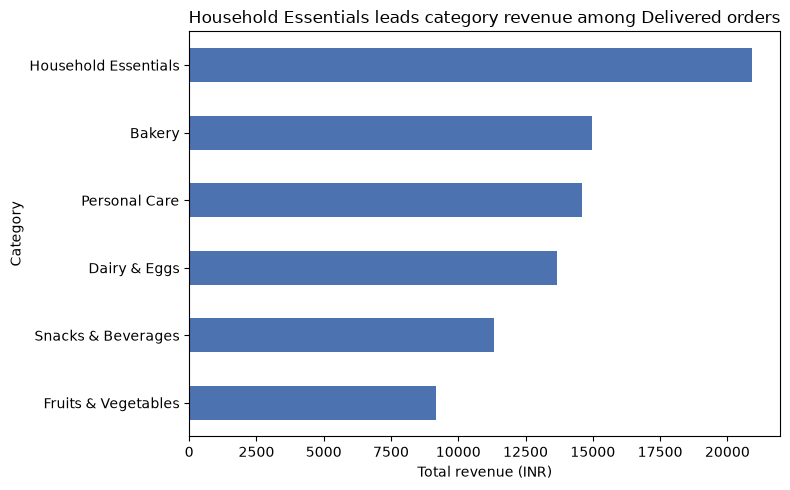

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
category_revenue.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title(f'{top_category} leads category revenue among Delivered orders')
ax.set_xlabel('Total revenue (INR)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

### Line chart of monthly revenue trend

In [23]:
monthly_revenue = delivered_orders.groupby(['month', 'month_name'])['amount_inr'].sum().reset_index().sort_values('month')
monthly_revenue

,month,month_name,amount_inr
0,1,January,10059.5
1,2,February,13715.0
2,3,March,14747.5
3,4,April,16558.5
4,5,May,16668.5
5,6,June,12888.0


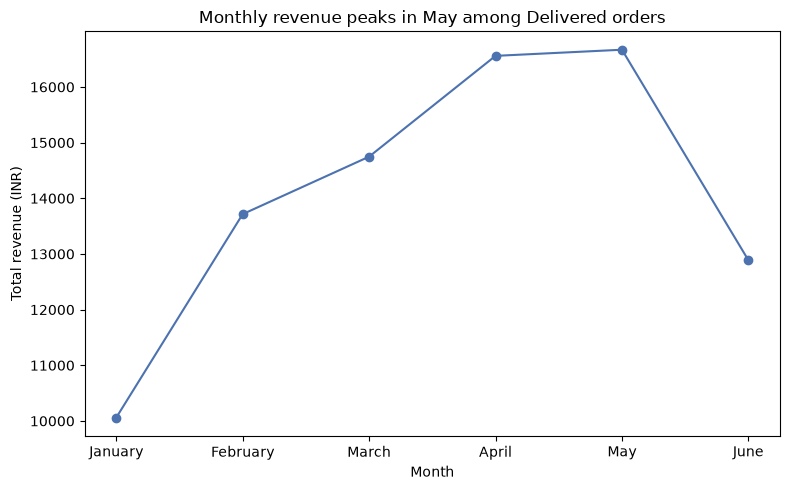

Peak month: May


In [24]:
peak_month = monthly_revenue.loc[monthly_revenue['amount_inr'].idxmax(), 'month_name']
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(monthly_revenue['month_name'], monthly_revenue['amount_inr'], marker='o', color='#4C72B0')
ax.set_title(f'Monthly revenue peaks in {peak_month} among Delivered orders')
ax.set_xlabel('Month')
ax.set_ylabel('Total revenue (INR)')
plt.tight_layout()
plt.show()
print('Peak month:', peak_month)

### Revenue by city

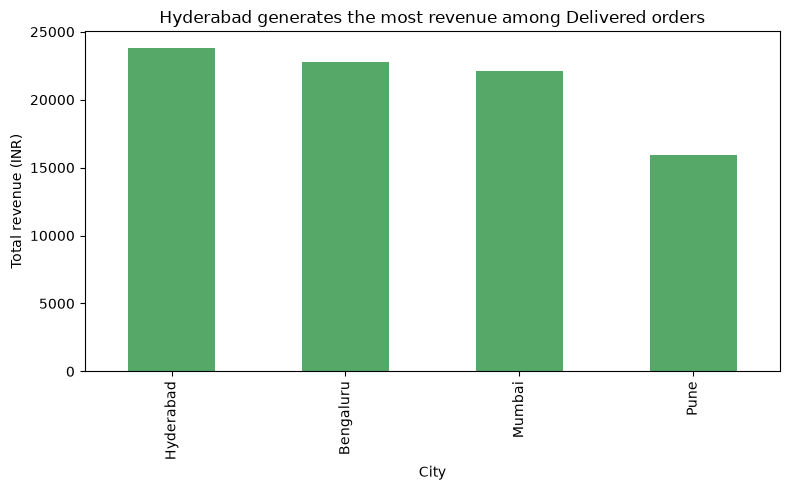

Top city by revenue: Hyderabad


city
Hyderabad    23840.0
Bengaluru    22775.5
Mumbai       22096.0
Pune         15925.5
Name: amount_inr, dtype: float64

In [25]:
city_revenue = delivered_orders.groupby('city')['amount_inr'].sum().sort_values(ascending=False)
top_city = city_revenue.idxmax()
fig, ax = plt.subplots(figsize=(8, 5))
city_revenue.plot(kind='bar', ax=ax, color='#55A868')
ax.set_title(f'{top_city} generates the most revenue among Delivered orders')
ax.set_xlabel('City')
ax.set_ylabel('Total revenue (INR)')
plt.tight_layout()
plt.show()
print('Top city by revenue:', top_city)
city_revenue

## Insights

1. Household Essentials is the top-revenue category among Delivered orders at 20,910 INR, and HomeEssentials Traders is the top supplier at the same 20,910 INR, matching the SQL diagnostic's findings.
   - Why it matters: revenue here is concentrated in a single category-supplier pair, so any disruption at HomeEssentials Traders puts a large share of revenue at risk.
   - Next step: evaluate onboarding a second supplier for Household Essentials to reduce single-supplier dependency.
2. Fruits & Vegetables is the lowest-revenue category at 9,170 INR, only about 44 percent of Household Essentials' revenue.
   - Why it matters: this category is the biggest drag on overall revenue and was already flagged as the largest shortfall against target in the dashboard data story.
   - Next step: run a pricing or promotion review specifically for Fruits & Vegetables next quarter.
3. Revenue by city is uneven: Hyderabad leads at 23,840 INR, followed by Bengaluru at 22,775.5 and Mumbai at 22,096, while Pune trails at 15,925.5, about 33 percent below Hyderabad.
   - Why it matters: marketing and inventory investment may be misallocated if Pune's lower revenue reflects an addressable gap rather than a smaller market.
   - Next step: investigate whether Pune's shortfall comes from fewer orders or a lower average order value, then target marketing spend accordingly.
